In [1]:
# PREVIOUS COMMANDS
import sys
!pip install ydata-profiling
!jupyter nbextension enable --py widgetsnbextension
!pip install matplotlib
!pip install graphviz
# 1. CORE LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. MACHINE LEARNING
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 3. SQL INTEGRATION (Run '!pip install pandasql' in a separate cell if not installed)
!pip install pandasql
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK
  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=a44e81ac4a35ef9d3d87e9e165f061b122bcff0b2812acb2d905acf8a9a970bc
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the CSV data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bank.csv')

*** DATA INSPECTION ***

In [4]:
#Load first 10 rows
df.index = pd.RangeIndex(start=1, stop=len(df) + 1)
print("Data loaded successfully! Here is a preview:")
df.head(10)

Data loaded successfully! Here is a preview:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
2,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
3,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
4,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
5,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
6,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
7,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
8,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
9,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
10,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


Before modeling, we need to understand the shape of our data. We are checking for missing values (often labeled as 'unknown' in this dataset), duplicate rows, and analyzing the distribution of our numerical data.


In [5]:
#Checking for Missing Values or Null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 1 to 4521
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [6]:
#Checking for duplicates
check_duplicates = df.duplicated().sum()
print(f"\nTotal duplicate rows: {check_duplicates}")


Total duplicate rows: 0


In [7]:
#Checking for "unkown" values
print("--- MISSING ('unknown') VALUES ---")
for col in df.columns:
    if df[col].dtype == 'object':
        unknown_count = (df[col] == 'unknown').sum()
        if unknown_count > 0:
            print(f"{col.capitalize()}: {unknown_count} unknown values")

--- MISSING ('unknown') VALUES ---
Job: 38 unknown values
Education: 187 unknown values
Contact: 1324 unknown values
Poutcome: 3705 unknown values


Poutcome has 82% unkown values as there are 4521 rows. Contact has 29% "unknown" values, Job is at 0.84% and education is at 4.14%. Below I imputed the values for Job and education. There were 15 rows where both job and education were unkown, for those i used the mode. For the rest, I based unkown job based on education level frequency and unkown education based on job frequency

In [8]:
# 1. Calculate the Mode (Most frequent value)
job_mode = df['job'].mode()[0]
edu_mode = df['education'].mode()[0]

# 2. Check the distribution (Better than mean/median for categories)
# This shows you if the mode is actually dominant or if it's a close race
job_counts = df['job'].value_counts(normalize=True) * 100
edu_counts = df['education'].value_counts(normalize=True) * 100

print(f"Job Mode: {job_mode}")
print(f"Education Mode: {edu_mode}")
print("\nTop 3 Jobs (%):\n", job_counts.head(3))
print("\nTop 3 education (%):\n", edu_counts.head(3))

Job Mode: management
Education Mode: secondary

Top 3 Jobs (%):
 job
management     21.433311
blue-collar    20.924574
technician     16.987392
Name: proportion, dtype: float64

Top 3 education (%):
 education
secondary    51.006415
tertiary     29.860650
primary      14.996682
Name: proportion, dtype: float64


In [9]:
import pandas as pd
# Create a subset of rows where either Job or Education is 'unknown' to know how many we need to impute and with what technique
missing_subset = df[(df['job'] == 'unknown') | (df['education'] == 'unknown')]

# Count the combinations, look at the table below to see how many of each catergory we have. Only 15 are unknown unknown
overlap = missing_subset.groupby(['job', 'education']).size().reset_index(name='count')
print(overlap)

# Specifically find rows missing BOTH
both_missing = df[(df['job'] == 'unknown') & (df['education'] == 'unknown')].shape[0]
print(f"Rows missing both Job and Education: {both_missing}")

              job  education  count
0          admin.    unknown     17
1     blue-collar    unknown     41
2    entrepreneur    unknown     11
3       housemaid    unknown      5
4      management    unknown     27
5         retired    unknown     14
6   self-employed    unknown      4
7        services    unknown     13
8         student    unknown     16
9      technician    unknown     22
10     unemployed    unknown      2
11        unknown    primary      7
12        unknown  secondary      8
13        unknown   tertiary      8
14        unknown    unknown     15
Rows missing both Job and Education: 15


In [10]:
# Identify rows where BOTH are unknown and fill with Mode for all databse
both_mask = (df['job'] == 'unknown') & (df['education'] == 'unknown')
df.loc[both_mask, 'job'] = 'management'
df.loc[both_mask, 'education'] = 'secondary'

print(f"Filled {both_mask.sum()} rows with global modes.")

Filled 15 rows with global modes.


In [11]:
#To sort the rest and to be able to impute job based on education and education based on job:
# 1. Map: Job -> Most frequent Education
job_to_edu_map = df[df['education'] != 'unknown'].groupby('job')['education'].agg(lambda x: x.value_counts().index[0]).to_dict()

# 2. Map: Education -> Most frequent Job
edu_to_job_map = df[df['job'] != 'unknown'].groupby('education')['job'].agg(lambda x: x.value_counts().index[0]).to_dict()

In [12]:
# Fill Education unknowns based on their Job
df.loc[df['education'] == 'unknown', 'education'] = df['job'].map(job_to_edu_map)

# Fill Job unknowns based on their Education
df.loc[df['job'] == 'unknown', 'job'] = df['education'].map(edu_to_job_map)

# Verification
print("Missing Jobs:", (df['job'] == 'unknown').sum())
print("Missing Education:", (df['education'] == 'unknown').sum())

Missing Jobs: 0
Missing Education: 0


In [13]:
#The values that remain unknown
print("--- MISSING ('unknown') VALUES ---")
for col in df.columns:
    if df[col].dtype == 'object':
        unknown_count = (df[col] == 'unknown').sum()
        if unknown_count > 0:
            print(f"{col.capitalize()}: {unknown_count} unknown values")

--- MISSING ('unknown') VALUES ---
Contact: 1324 unknown values
Poutcome: 3705 unknown values


In [14]:
#When poutcome = unknown, pdays = -1 (not contacted) and previous = 0 (no contact)
count_test = ((df['pdays'] == -1) & (df['previous'] == 0) & (df['poutcome'] == 'unknown')).sum()
print(count_test)


3705


In [15]:
#Finding Count, Max, Min, Mean, Standard deviation
print(df.describe().round(3))
print("\n")

            age    balance       day  duration  campaign     pdays  previous
count  4521.000   4521.000  4521.000  4521.000  4521.000  4521.000  4521.000
mean     41.170   1422.658    15.915   263.961     2.794    39.767     0.543
std      10.576   3009.638     8.248   259.857     3.110   100.121     1.694
min      19.000  -3313.000     1.000     4.000     1.000    -1.000     0.000
25%      33.000     69.000     9.000   104.000     1.000    -1.000     0.000
50%      39.000    444.000    16.000   185.000     2.000    -1.000     0.000
75%      49.000   1480.000    21.000   329.000     3.000    -1.000     0.000
max      87.000  71188.000    31.000  3025.000    50.000   871.000    25.000




In [16]:
# Show frequency & percentages (rounded to two decimals) for categorical variables
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"\n{col.capitalize()} Frequency:")
        print(df[col].value_counts().sort_values(ascending=False))
        print("\nPercentage:")
        print(round(df[col].value_counts(normalize=True) *
                    100, 2).sort_values(ascending=False))
        print("\n")
        print("-" * 50)


Job Frequency:
job
management       992
blue-collar      961
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
Name: count, dtype: int64

Percentage:
job
management       21.94
blue-collar      21.26
technician       16.99
admin.           10.57
services          9.22
retired           5.09
self-employed     4.05
entrepreneur      3.72
unemployed        2.83
housemaid         2.48
student           1.86
Name: proportion, dtype: float64


--------------------------------------------------

Marital Frequency:
marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64

Percentage:
marital
married     61.87
single      26.45
divorced    11.68
Name: proportion, dtype: float64


--------------------------------------------------

Education Frequency:
education
secondary    2446
tertiary     1392
primary       683
Name: count, dt

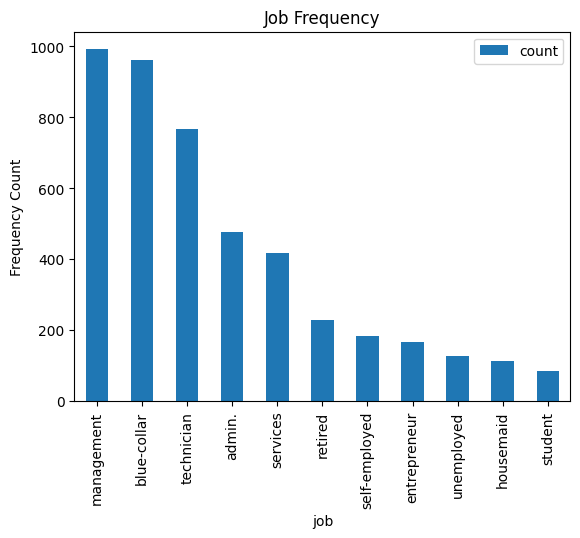

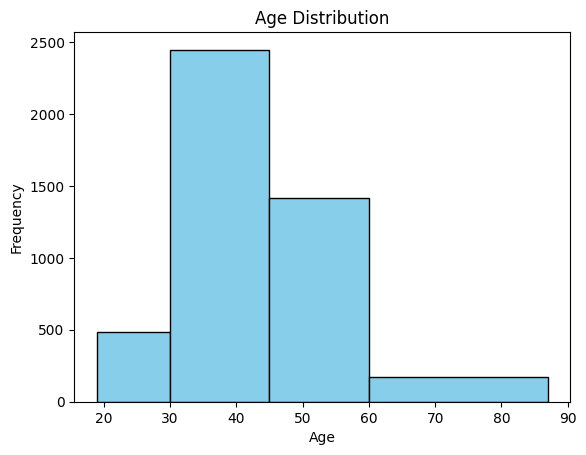

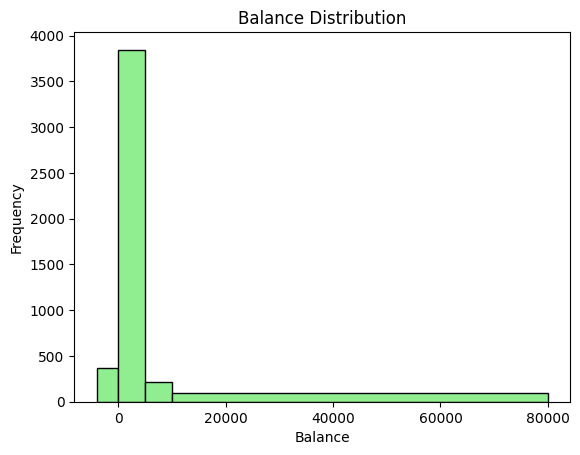

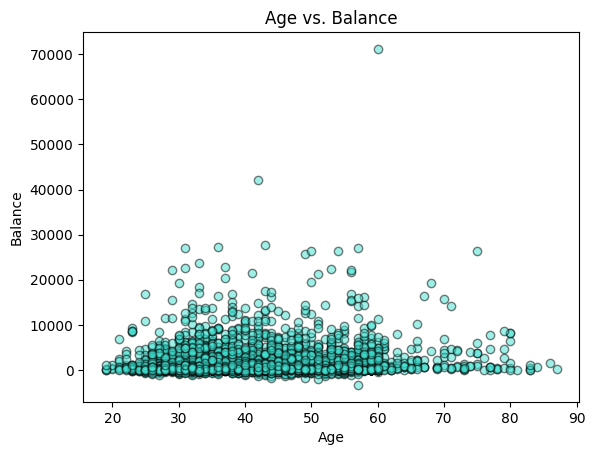

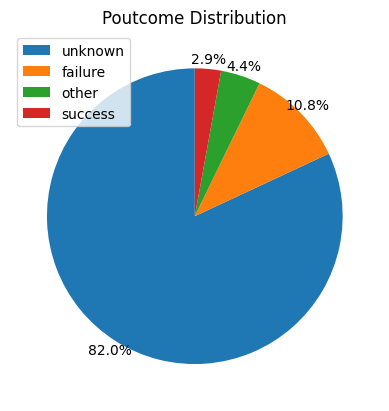

In [17]:
#Graphs for Presentation - WIP
df_pres = df.copy(deep=True)
#df_pres = df_pres.select_dtypes(exclude=[np.number])
#df_pres.apply(pd.Series.value_counts).T.plot(kind='bar', stacked=True)

#plt.title("Category Frequency per Column")
#plt.ylabel("Frequency Count")
#plt.show()

#Job - Bar Graph
df_pres_job = pd.DataFrame(df_pres['job'].value_counts())
df_pres_job.plot.bar(stacked=True)
plt.title("Job Frequency")
plt.ylabel("Frequency Count")
plt.show()

# Age: Histograms displays the age groups (young, early mid, late mid, and senior)
# <30 = young, 30<x<45 = early mid, 46<x<60 = late mid, 61+ = senior
plt.hist(df_pres['age'], bins=[19, 30, 45, 60, 87], color='skyblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Balance: Histogram - bins separated in our defined balance groups
plt.hist(df_pres['balance'], bins=[-4000, 0, 5000, 10000, 80000], color='lightgreen', edgecolor='black')
plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

#Age vs Balance

plt.scatter(df_pres['age'], df_pres['balance'], color='turquoise', alpha=0.5, edgecolor='black')
plt.title("Age vs. Balance")
plt.xlabel("Age")
plt.ylabel("Balance")
plt.show()

#Poutcome Pie-Chart = maybe good to show how many unknowns we are dealing with to the audience
poutcome_counts = df_pres['poutcome'].value_counts()
plt.pie(poutcome_counts, autopct='%1.1f%%', pctdistance=1.07, startangle=90)
plt.title("Poutcome Distribution")
plt.legend(poutcome_counts.index)
plt.show()



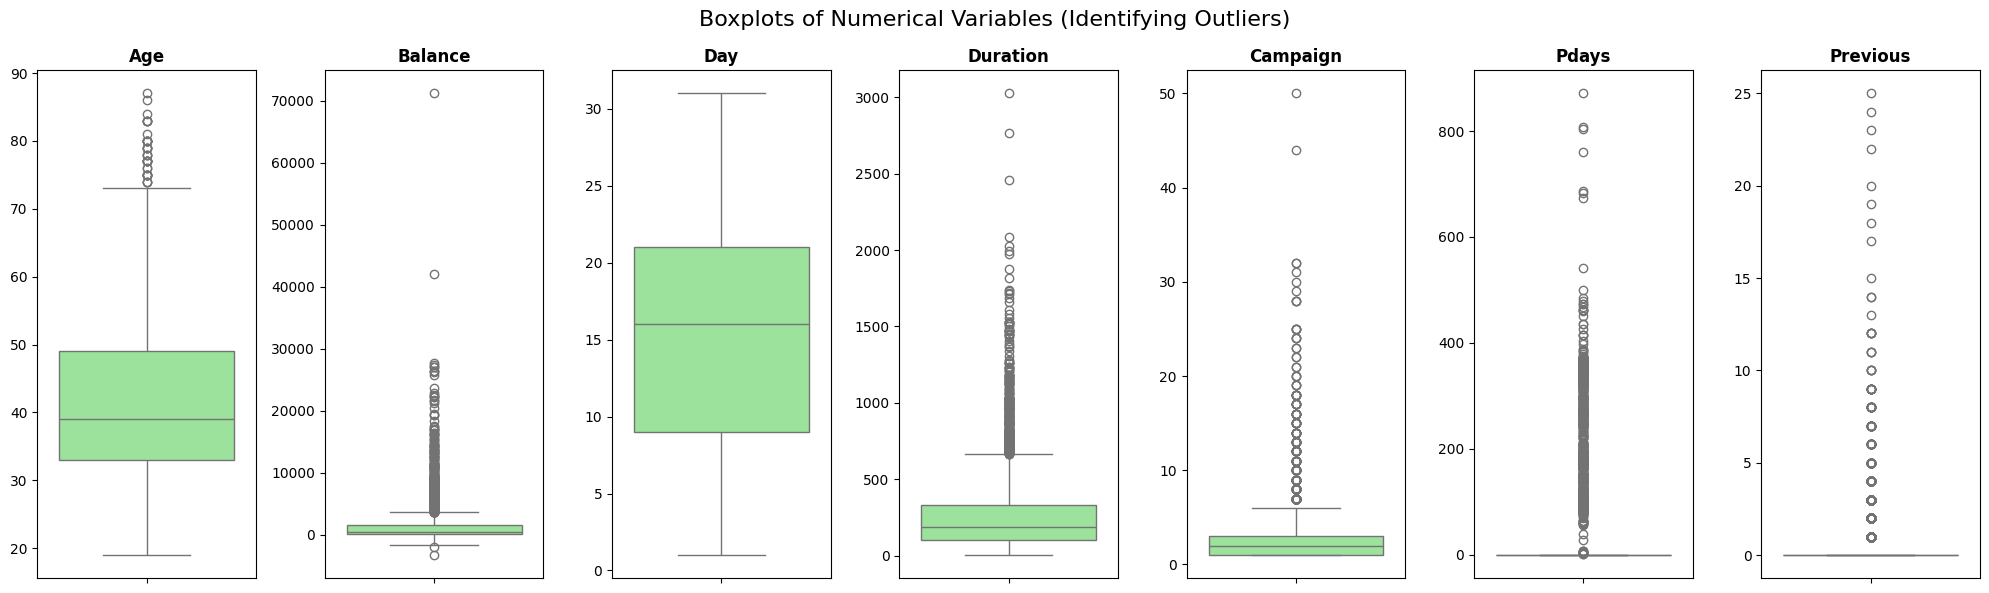

In [18]:
# Visualizing distributions to spot outliers
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 6))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col.capitalize(), fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')

plt.suptitle("Boxplots of Numerical Variables (Identifying Outliers)", fontsize=16)
plt.tight_layout()
plt.show()

Previous, Pdays, Campaign, and Duration all have a large amount of outliers and very small box plots.

Number of 'Unknown' contacts who said YES: 61

Success Rate by Contact Method (%):
contact
cellular     14.364641
telephone    14.617940
unknown       4.607251
Name: y, dtype: float64


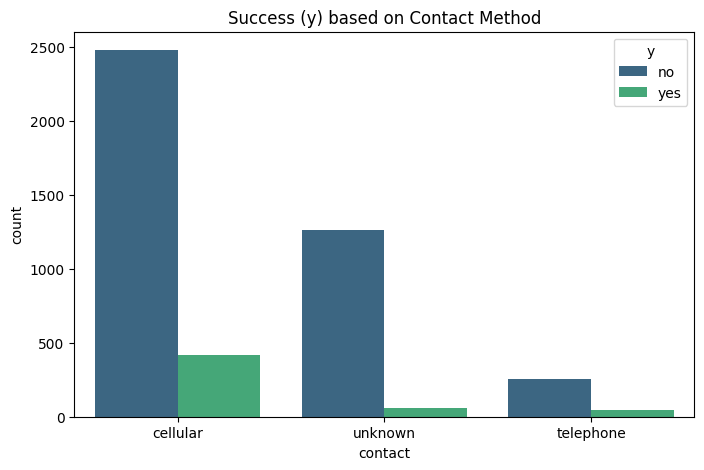

In [19]:
# 1. Check if any 'unknown' contact methods resulted in a 'yes'
unknown_contact_yes = df[(df['contact'] == 'unknown') & (df['y'] == 'yes')]

# 2. Calculate the percentage of success for unknown contacts vs others
contact_success_rate = df.groupby('contact')['y'].apply(lambda x: (x == 'yes').mean() * 100)

print(f"Number of 'Unknown' contacts who said YES: {len(unknown_contact_yes)}")
print("\nSuccess Rate by Contact Method (%):")
print(contact_success_rate)

# 3. Visualizing the Contact Method vs Success
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='contact', hue='y', palette='viridis')
plt.title('Success (y) based on Contact Method')
plt.show()

*** DATA PREPARATIONS ***

** REMOVING OUTLIERS IN BALANCE **

New Measures of Central Tendency
            age    balance       day  duration  campaign     pdays  previous
count  4519.000   4519.000  4519.000  4519.000  4519.000  4519.000  4519.000
mean     41.166   1398.230    15.919   263.987     2.794    39.785     0.543
std      10.575   2760.217     8.247   259.911     3.110   100.140     1.694
min      19.000  -3313.000     1.000     4.000     1.000    -1.000     0.000
25%      33.000     69.000     9.000   104.000     1.000    -1.000     0.000
50%      39.000    444.000    16.000   185.000     2.000    -1.000     0.000
75%      49.000   1477.000    21.000   329.500     3.000    -1.000     0.000
max      87.000  27733.000    31.000  3025.000    50.000   871.000    25.000




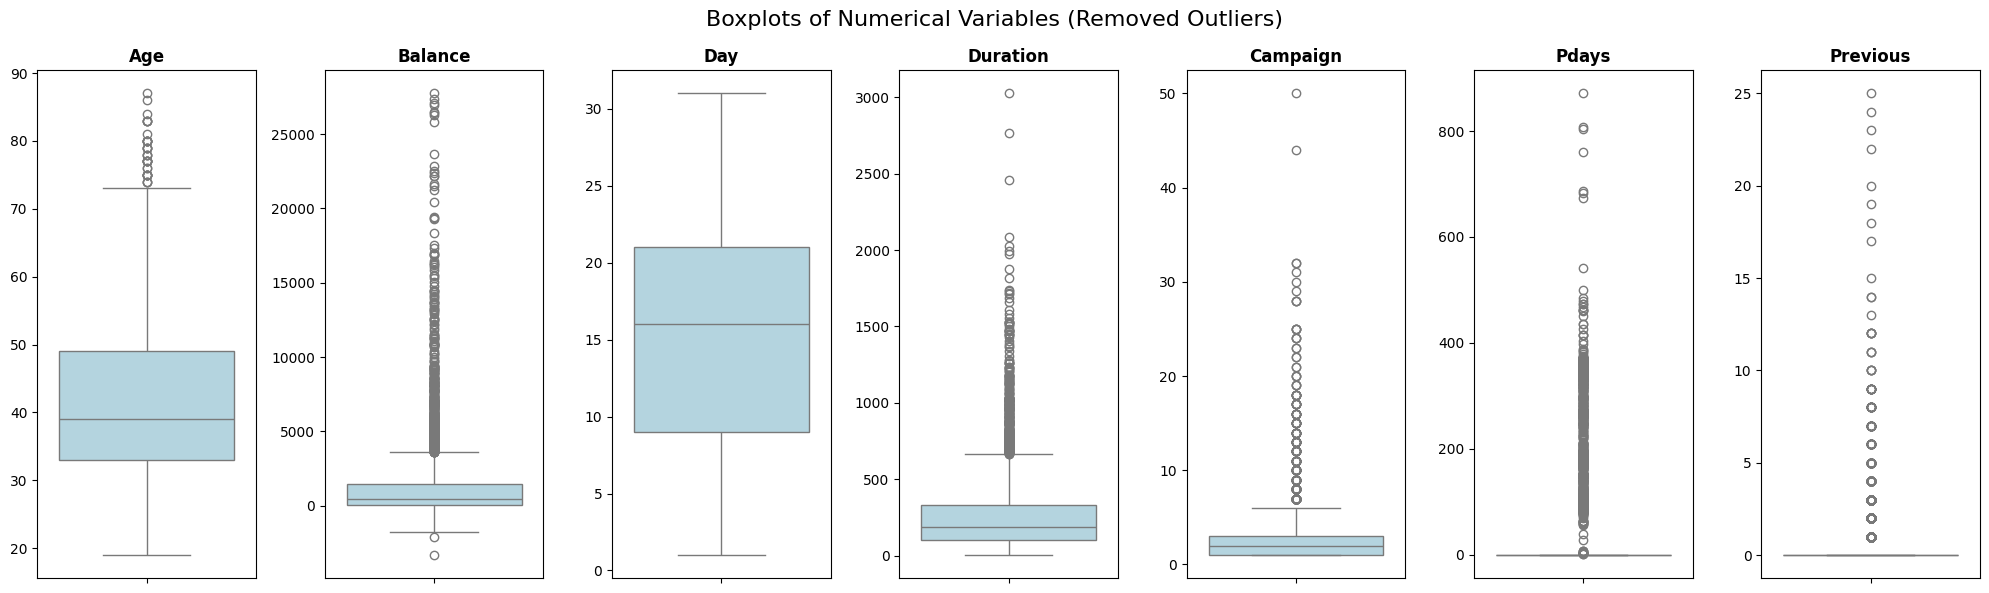

In [20]:
df_prep = df.copy(deep=True)

df_prep = df_prep.rename(columns={'y': 'subscription'})

#Dataframe - Removing Outliers: balance
df_prep = df_prep[~(df_prep['balance'] > 40000)] # ~ selects the inverse
#df_prep = df_prep[~(df_prep['balance'] < 1)] #Removing negatives & 0s


##
#Dataframe - Removing Outliers: duration
#df_prep = df_prep[~(df_prep['duration'] > 2200)]

#Dataframe - Removing Outliers: campaign
#df_prep = df_prep[~(df_prep['campaign'] > 40)]

#Dataframe - Removing Outliers: pdays
#df_prep = df_prep[~(df_prep['pdays'] > 600)]
##


#Reset the index
df_prep.reset_index(drop=True, inplace=True)
df_prep.index = pd.RangeIndex(start=1, stop=len(df_prep) + 1)

#df_prep.info()
#print(len(df_prep))

# --- DROPPING POUTCOMES DUE TO 3705 Unknowns = 81% of data
#df_prep = df_prep.drop(columns=['poutcome'])

#Finding Count, Max, Min, Mean, Standard deviation
print("New Measures of Central Tendency")
print(df_prep.describe().round(3))
print("\n")

# Visualizing distributions
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 6))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df_prep[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col.capitalize(), fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')

plt.suptitle("Boxplots of Numerical Variables (Removed Outliers)", fontsize=16)
plt.tight_layout()
plt.show()

#df_prep.info()

 - Creating a copy of data frame and mapping categorical values
 - Adding Groups for Age and Balance into the dataframe
 - need to decide what to do with all the columns

In [21]:
# Create a copy
df_model = df_prep.copy()

# --- STEP 1: BINNING (Age & Balance) ---
# We map directly to integers (0, 1, 2, 3) to skip the middle-man string mapping.

# Age Binning
conditions_age = [
    (df_model['age'] < 30),
    (df_model['age'] >= 30) & (df_model['age'] <= 45),
    (df_model['age'] >= 46) & (df_model['age'] <= 60),
    (df_model['age'] > 60)
]
choice_age = ['young', 'early_mid', 'late_mid', 'senior']
df_model['age_group'] = np.select(conditions_age, choice_age, default='unknown')


# Define Balance Groups
conditions_balance = [
    (df_model['balance'] < 0),
    (df_model['balance'] >= 0) & (df_model['balance'] <= 5000),
    (df_model['balance'] > 5000) & (df_model['balance'] <= 10000),
    (df_model['balance'] > 10000),
]
choice_balance = ['negative', 'low', 'medium', 'high']
df_model['balance_group'] = np.select(conditions_balance, choice_balance, default='unknown')

# --- STEP 2: ORDINAL & BINARY MAPPING ---
# MANUAL MAPPING (Ordinal & Binary)
maps = {
    'month': {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
              'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12},
    'education': {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3},
    'marital': {'single': 0, 'married': 1, 'divorced': 2},
    'binary': {'no': 0, 'yes': 1},
    'age_group': {'young': 0, 'early_mid': 1, 'late_mid': 2, 'senior': 3},
    'balance_group': {'negative': 0, 'low': 1, 'medium': 2, 'high': 3}
}

# Applying mappings
df_model['month'] = df_model['month'].map(maps['month'])
df_model['education'] = df_model['education'].map(maps['education'])
df_model['marital'] = df_model['marital'].map(maps['marital'])
df_model['age_group'] = df_model['age_group'].map(maps['age_group']) #Un-comment if, you want to keep the extra column in the dataframe
df_model['age'] = df_model['age_group'].map(maps['age_group']) #comment-out if, you don't want to directly change the column values.
df_model['balance_group'] = df_model['balance_group'].map(maps['balance_group']) #comment-out if, you want don't want the extra column in the dataframe
df_model['balance'] = df_model['balance_group'].map(maps['balance_group']) #Un-comment if, you want to use the GROUPINGS instead of the original values; but you'll have to comment out the log transformation
# Applying binary maps to multiple columns
for col in ['default', 'housing', 'loan', 'subscription']:
    if col in df_model.columns:
        df_model[col] = df_model[col].map(maps['binary'])

# --- STEP 3: LOG TRANSFORMATION---

# Log Transformations (Addressing skewness)
# Note: Using a fixed shift for balance helps with consistency across datasets

#Balance
min_balance = df_model['balance_group'].min()
df_model['log_balance'] = np.log1p(df_model['balance_group'] - min_balance + 1) #indices for df_prep and df_model are the same, so we can just add these columns to df_model.

#Duration
df_model['log_duration'] = np.log1p(df_model['duration'] + 1)

#Dropping columns age, balance, and duration after Mapping since we have the two groups now
df_model.drop(columns=['age'], inplace=True) # Prevent double-counting
df_model.drop(columns=['duration'], inplace=True) # Prevent double-counting
df_model.drop(columns=['balance'], inplace=True) # Prevent double-counting

# --- STEP 4: ONE-HOT ENCODING (Nominal variables) ---
# 'job', 'contact', 'poutcome', AND 'marital' have no mathematical hierarchy.
# We use get_dummies instead of LabelEncoder to prevent Naive Bayes from assuming order.
# drop_first=True prevents the "Dummy Variable Trap" (multicollinearity).

nominal_columns = ['job', 'contact', 'poutcome']
df_model = pd.get_dummies(df_model, columns=nominal_columns, drop_first=True, dtype=int)

# --- FINAL CHECK ---
print("Dataset shape after preparation:", df_model.shape)
df_model.head()
# 2. Final Check
print(f"Final feature count: {df_model.shape[1]}")
print(df_model.columns.tolist())


Dataset shape after preparation: (4519, 30)
Final feature count: 30
['marital', 'education', 'default', 'housing', 'loan', 'day', 'month', 'campaign', 'pdays', 'previous', 'subscription', 'age_group', 'balance_group', 'log_balance', 'log_duration', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'contact_telephone', 'contact_unknown', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


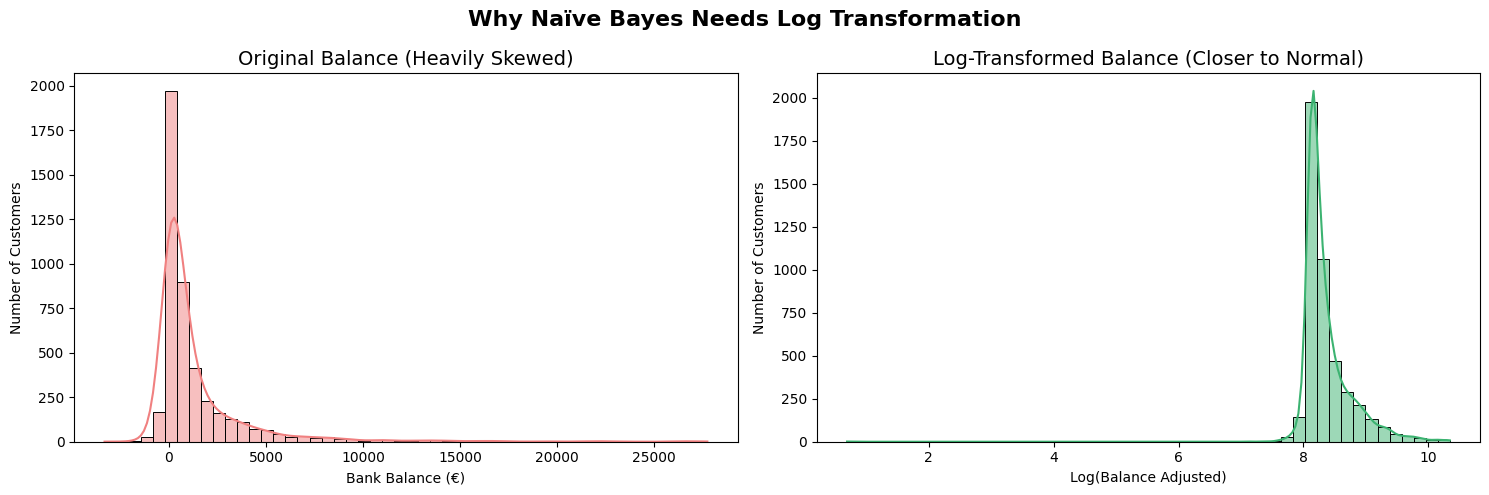

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Plot 1: The Original Skewed Data ---
# Use the ORIGINAL dataframe before any binning/grouping occurred
sns.histplot(df_prep['balance'], bins=50, ax=axes[0], color='lightcoral', kde=True)
axes[0].set_title('Original Balance (Heavily Skewed)', fontsize=14)
axes[0].set_xlabel('Bank Balance (€)')
axes[0].set_ylabel('Number of Customers')

# --- Plot 2: The Log-Transformed Data ---
# We use np.log1p(x - min + 1) to ensure all values are positive before logging
# This creates a much smoother distribution for the model to work with
min_bal = df_prep['balance'].min()
log_data = np.log1p(df_prep['balance'] - min_bal + 1)

sns.histplot(log_data, bins=50, ax=axes[1], color='mediumseagreen', kde=True)
axes[1].set_title('Log-Transformed Balance (Closer to Normal)', fontsize=14)
axes[1].set_xlabel('Log(Balance Adjusted)')
axes[1].set_ylabel('Number of Customers')

plt.suptitle('Why Naïve Bayes Needs Log Transformation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Unlike the Decision Tree, the Naïve Bayes model relies on Gaussian probability (the Bell Curve). When we explored our data, we found that financial attributes like balance were heavily right-skewed.

If we fed the raw balance data to the Bayes model, it would struggle. Below, we visualize why we applied the Log Transformation: it pulls the extreme outliers in and creates a much more "normal" bell curve shape, allowing the Naïve Bayes math to work correctly.

**Machine learning models** require numerical inputs. Instead of letting the computer assign random alphabetical numbers to our categories (like LabelEncoder does), we manually mapped ordinal variables like Education (0 to 3) and binary variables (0 or 1). This ensures the model understands the logical progression of the data.

We also noticed our financial data (balance) and call duration are heavily right-skewed. We are applying a Log Transformation to normalize these distributions, which drastically improves the accuracy of models like Naïve Bayes.

** BONUS - SQL ** AND HEAT MAP

To go beyond standard analysis, we used SQL logic inside Python to aggregate our subscriber data, alongside an interactive heatmap to see which variables most strongly drive a successful "yes" outcome.

In [23]:
# SQL Query to determine if stratified sampling is needed
query = """
SELECT
    y as Subscribed,
    COUNT(*) as Total_Customers,
    ROUND(AVG(age), 1) as Avg_Age,
    ROUND(AVG(balance), 2) as Avg_Balance
FROM df
GROUP BY y
"""
print("--- SQL Analysis of Subscribers ---")
display(pysqldf(query))

--- SQL Analysis of Subscribers ---


,Subscribed,Total_Customers,Avg_Age,Avg_Balance
0,no,4000,41.0,1403.21
1,yes,521,42.5,1571.96


The heatmap shows that Duration is the strongest correlate. However, as data scientists, we recognized this as a trap (Reverse Causality), which is why we built a second, filtered model for actual business use.

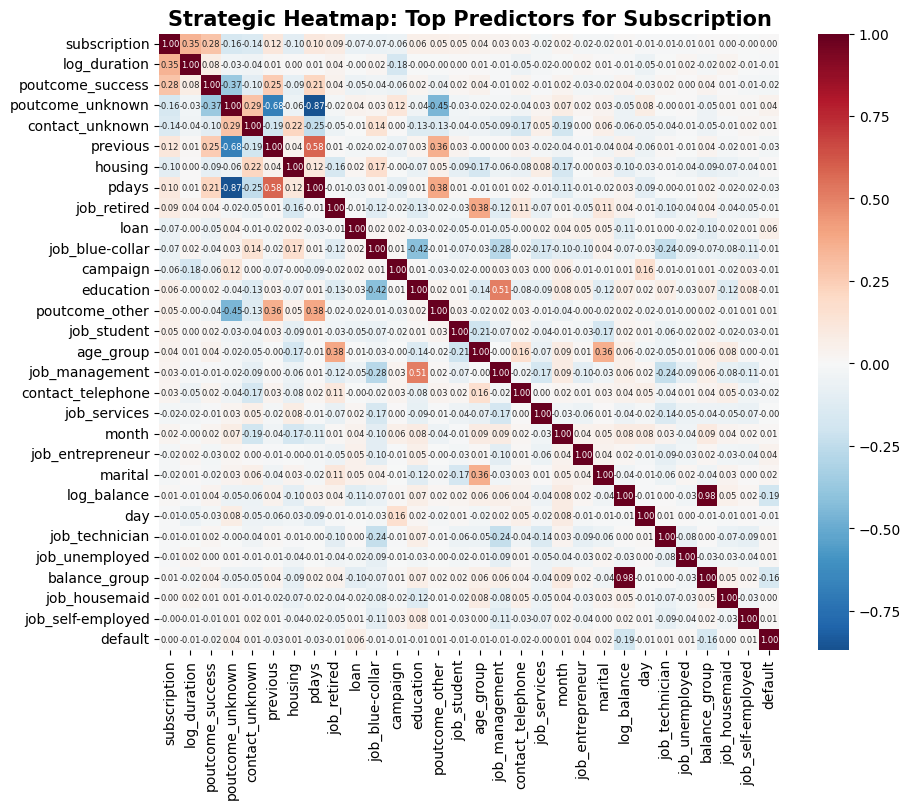

In [24]:
# Identify the top 15 variables correlated with subscription
# We use .abs() to find the strongest relationships, whether positive or negative
top_corr_features = df_model.corr()['subscription'].abs().sort_values(ascending=False).head(40).index
#print(top_corr_features)

# Visualize the correlation heatmap
plt.figure(figsize=(10, 8))

# Plotting the correlations of just these top features
sns.heatmap(df_model[top_corr_features].corr(), annot=True, annot_kws={"size": 6}, cmap='RdBu_r',center=0, fmt='.2f')

plt.title('Strategic Heatmap: Top Predictors for Subscription', fontsize=15, fontweight='bold')
plt.show()

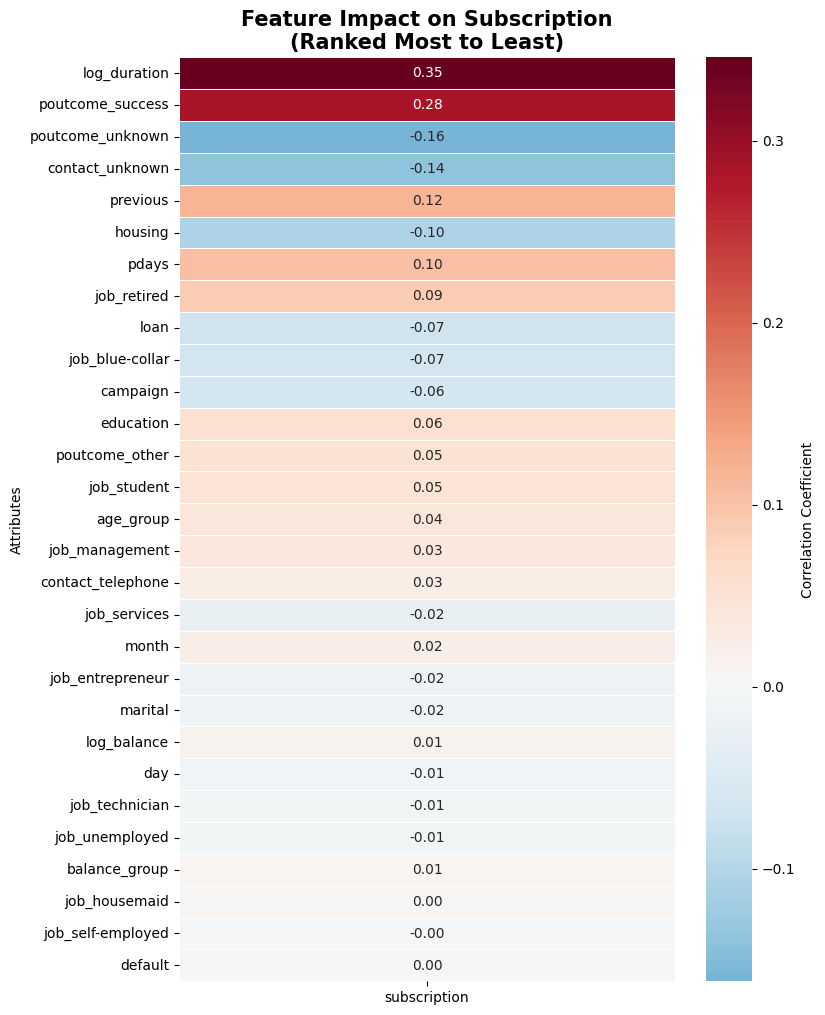

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the correlation matrix
corr_matrix = df_model.corr()

# 2. Isolate the 'subscription' column and drop the 'subscription' row itself (since it's always 1.0)
impact = corr_matrix[['subscription']].drop(labels=['subscription'])

# 3. Sort by absolute value to get the "most impactful" (positive or negative) at the top
impact['abs_impact'] = impact['subscription'].abs()
impact_sorted = impact.sort_values(by='abs_impact', ascending=False).drop(columns=['abs_impact'])

# 4. Visualize
plt.figure(figsize=(8, 12))
sns.heatmap(impact_sorted,
            annot=True,
            cmap='RdBu_r',
            center=0,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Feature Impact on Subscription\n(Ranked Most to Least)', fontsize=15, fontweight='bold')
plt.ylabel('Attributes')
plt.show()

*** MACHINE LEARNING ***

** Predictive Modeling (Decision Tree vs. Naïve Bayes) **

We split our dataset into a 80% training set and a 20% testing set. We are comparing a Decision Tree (great for interpretability) and a Gaussian Naïve Bayes model (great for probability).

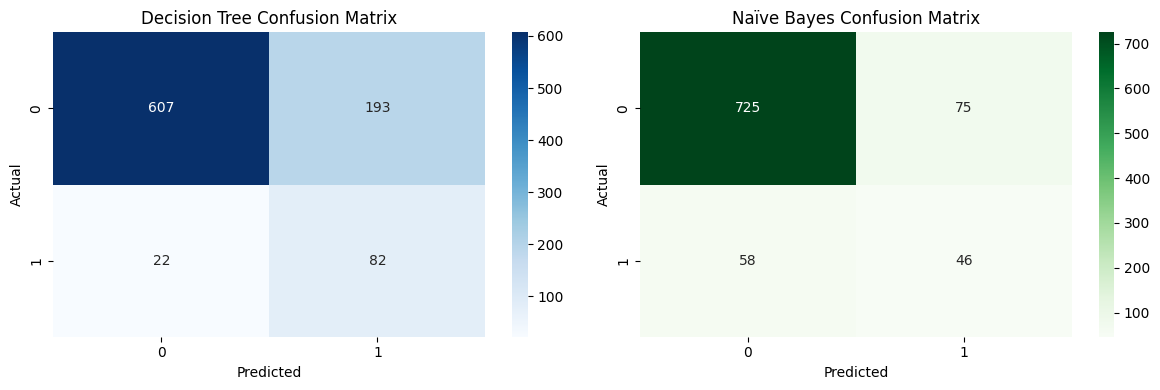

In [26]:
# Define Features (X) and Target (y)
X = df_model.drop('subscription', axis=1)
y = df_model['subscription']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #With stratify sampling the Accuracy increases a bit

# 1. Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# 2. Train Naïve Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# Visualizing Confusion Matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Decision Tree Confusion Matrix')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Naïve Bayes Confusion Matrix')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

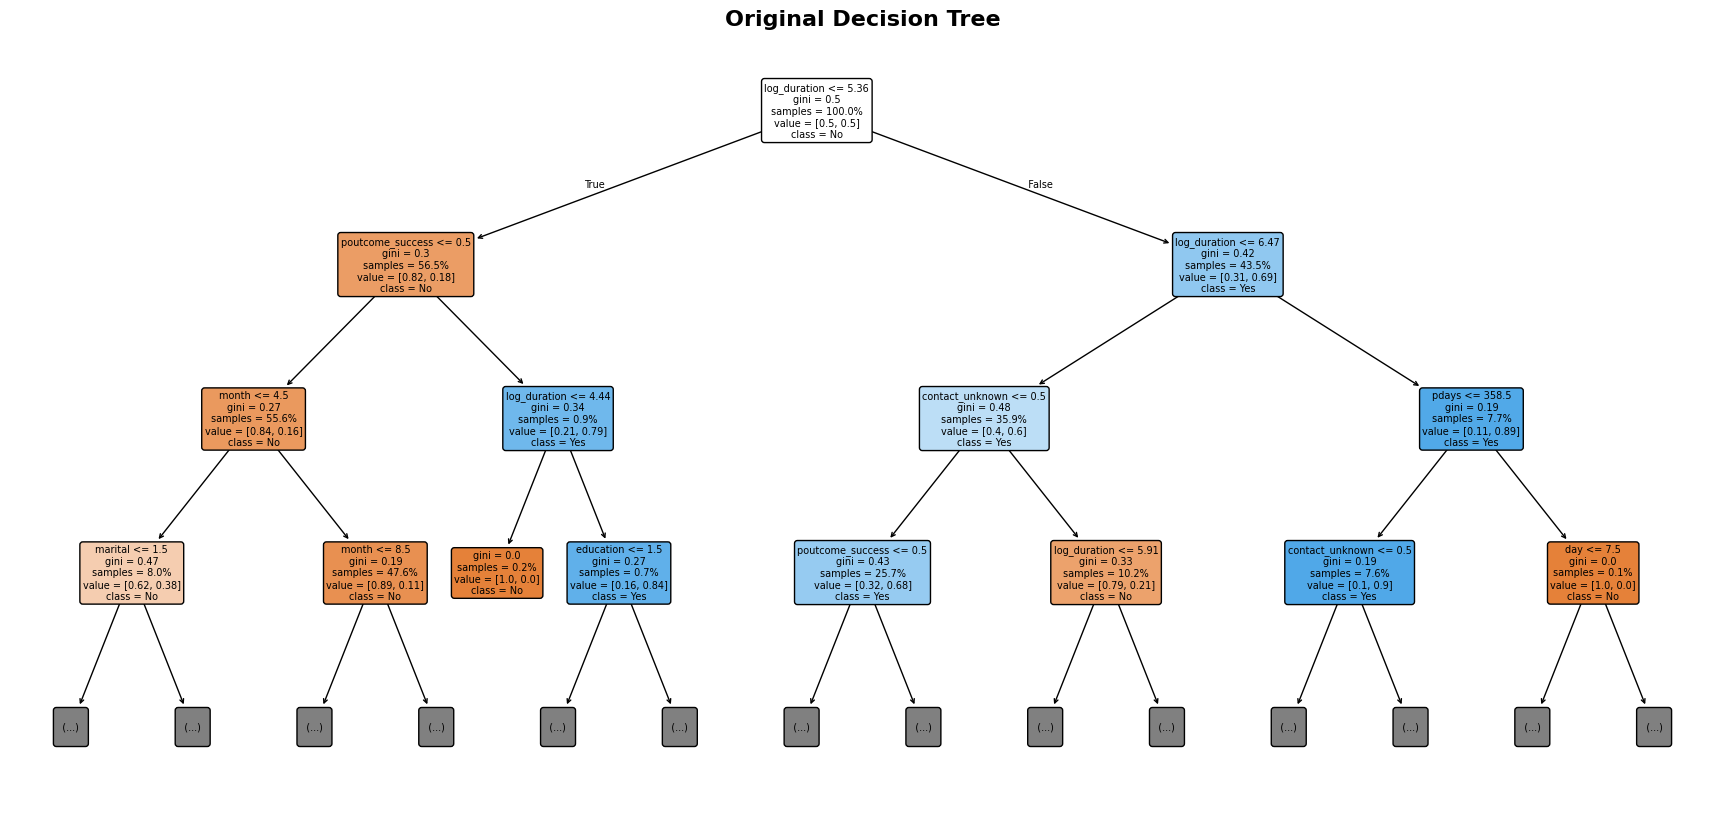

In [27]:
# --- ORIGINAL TREE---
# This matches your original dt_model
plt.figure(figsize=(22, 10))

plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          proportion=True, # Shows percentages to make it easier to read
          precision=2,
          max_depth=3, # For readability keeping it to 3 levels
          fontsize=7)

plt.title('Original Decision Tree', fontsize=16, fontweight='bold')
plt.show()

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics

# To print metrics cleanly
def print_metrics(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn)
    f1 = f1_score(y_true, y_pred)

    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"FPR:       {fpr:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")

# Print the results
print_metrics("Decision Tree", y_test, dt_preds)
print_metrics("Naïve Bayes", y_test, nb_preds)

#Classification Report
print(classification_report(y_test, dt_preds))
print(classification_report(y_test, nb_preds))
#inbalance data = look for macro avg

--- Decision Tree ---
Accuracy:  0.7622
Precision: 0.2982
Recall:    0.7885
FPR:       0.2412
F1-Score:  0.4327

--- Naïve Bayes ---
Accuracy:  0.8529
Precision: 0.3802
Recall:    0.4423
FPR:       0.0938
F1-Score:  0.4089

              precision    recall  f1-score   support

           0       0.97      0.76      0.85       800
           1       0.30      0.79      0.43       104

    accuracy                           0.76       904
   macro avg       0.63      0.77      0.64       904
weighted avg       0.89      0.76      0.80       904

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       800
           1       0.38      0.44      0.41       104

    accuracy                           0.85       904
   macro avg       0.65      0.67      0.66       904
weighted avg       0.86      0.85      0.86       904



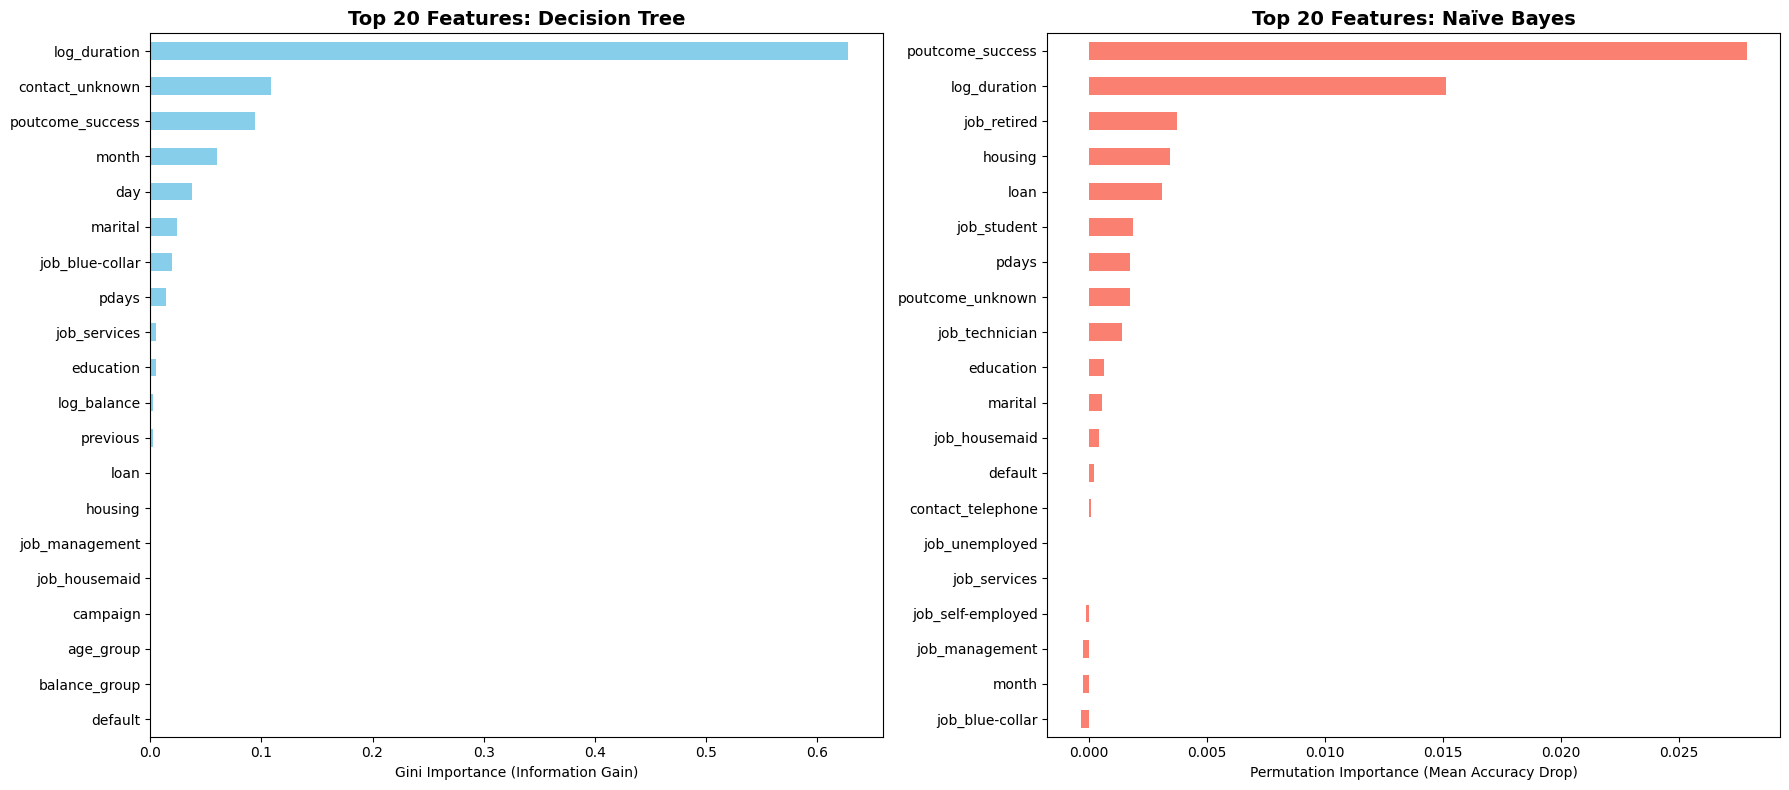

--- Top 20: Decision Tree ---
log_duration        0.628101
contact_unknown     0.108581
poutcome_success    0.093912
month               0.060331
day                 0.037251
marital             0.023988
job_blue-collar     0.019549
pdays               0.013820
job_services        0.005321
education           0.004658
log_balance         0.002374
previous            0.002115
default             0.000000
balance_group       0.000000
age_group           0.000000
campaign            0.000000
loan                0.000000
housing             0.000000
job_management      0.000000
job_housemaid       0.000000
dtype: float64

--- Top 20: Naïve Bayes ---
poutcome_success     2.787611e-02
log_duration         1.515487e-02
job_retired          3.761062e-03
housing              3.429204e-03
loan                 3.097345e-03
job_student          1.880531e-03
pdays                1.769912e-03
poutcome_unknown     1.769912e-03
job_technician       1.438053e-03
education            6.637168e-04
marita

In [29]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Decision Tree Feature Importance ---
# Uses the model's internal Gini importance (Information Gain)
dt_importances = pd.Series(dt_model.feature_importances_, index=X.columns)
dt_top_20 = dt_importances.sort_values(ascending=False).head(20)

# --- 2. Naïve Bayes Feature Importance ---
# Uses Permutation Importance (How much accuracy drops if we shuffle a feature)
# We use the test set to see what actually helped it generalize
nb_perm_importance = permutation_importance(nb_model, X_test, y_test, n_repeats=10, random_state=42)
nb_importances = pd.Series(nb_perm_importance.importances_mean, index=X.columns)
nb_top_20 = nb_importances.sort_values(ascending=False).head(20)

# --- 3. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Decision Tree Plot
dt_top_20.sort_values().plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title('Top 20 Features: Decision Tree', fontsize=14, fontweight='bold')
ax1.set_xlabel('Gini Importance (Information Gain)')

# Naïve Bayes Plot
nb_top_20.sort_values().plot(kind='barh', ax=ax2, color='salmon')
ax2.set_title('Top 20 Features: Naïve Bayes', fontsize=14, fontweight='bold')
ax2.set_xlabel('Permutation Importance (Mean Accuracy Drop)')

plt.tight_layout()
plt.show()

# --- 4. Print Ranked Lists ---
print("--- Top 20: Decision Tree ---")
print(dt_top_20)
print("\n--- Top 20: Naïve Bayes ---")
print(nb_top_20)

In [30]:
# Rerunning Decision Tree and Naive Bayes based on the 13 features indicated by the baseline Decision Tree model.
# 1. Define the 13 Selected Features
selected_features = [
    'log_duration', 'poutcome_success', 'pdays', 'contact_unknown',
    'day', 'housing', 'age_group', 'job_retired', 'job_student',
    'log_balance', 'marital', 'month', 'campaign'
]

# 2. Prepare the data using the proper Train/Test split
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# 3. Running Decision Tree on the selected features
dt_model_v3 = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt_model_v3.fit(X_train_selected, y_train)  # Train on training data
dt_preds_v3 = dt_model_v3.predict(X_test_selected) # Predict on unseen test data

# 4. Running Naive Bayes on the selected features
nb_model_v3 = GaussianNB()
nb_model_v3.fit(X_train_selected, y_train)  # Train on training data
nb_preds_v3 = nb_model_v3.predict(X_test_selected) # Predict on unseen test data

# 5. Calculate metrics using y_test (The real-world validation)
print_metrics("Decision Tree (Selected 13 Features)", y_test, dt_preds_v3)
print_metrics("Naïve Bayes (Selected 13 Features)", y_test, nb_preds_v3)

--- Decision Tree (Selected 13 Features) ---
Accuracy:  0.7223
Precision: 0.2724
Recall:    0.8462
FPR:       0.2938
F1-Score:  0.4122

--- Naïve Bayes (Selected 13 Features) ---
Accuracy:  0.8717
Precision: 0.4333
Recall:    0.3750
FPR:       0.0638
F1-Score:  0.4021



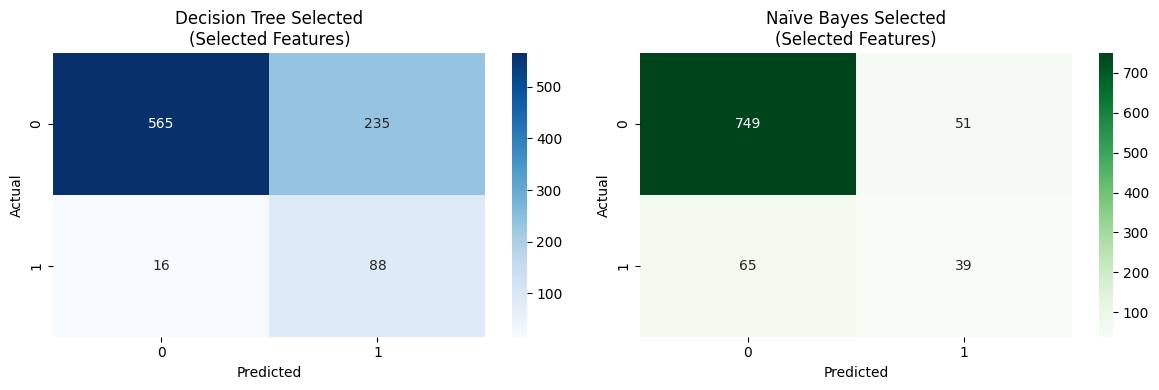

In [31]:
# Visual Comparison: Confusion Matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, dt_preds_v3), annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Decision Tree Selected\n(Selected Features)')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, nb_preds_v3), annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Naïve Bayes Selected\n(Selected Features)')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [32]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4519 entries, 1 to 4519
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   marital            4519 non-null   int64  
 1   education          4519 non-null   int64  
 2   default            4519 non-null   int64  
 3   housing            4519 non-null   int64  
 4   loan               4519 non-null   int64  
 5   day                4519 non-null   int64  
 6   month              4519 non-null   int64  
 7   campaign           4519 non-null   int64  
 8   pdays              4519 non-null   int64  
 9   previous           4519 non-null   int64  
 10  subscription       4519 non-null   int64  
 11  age_group          4519 non-null   int64  
 12  balance_group      4519 non-null   int64  
 13  log_balance        4519 non-null   float64
 14  log_duration       4519 non-null   float64
 15  job_blue-collar    4519 non-null   int64  
 16  job_entrepreneur   4519 

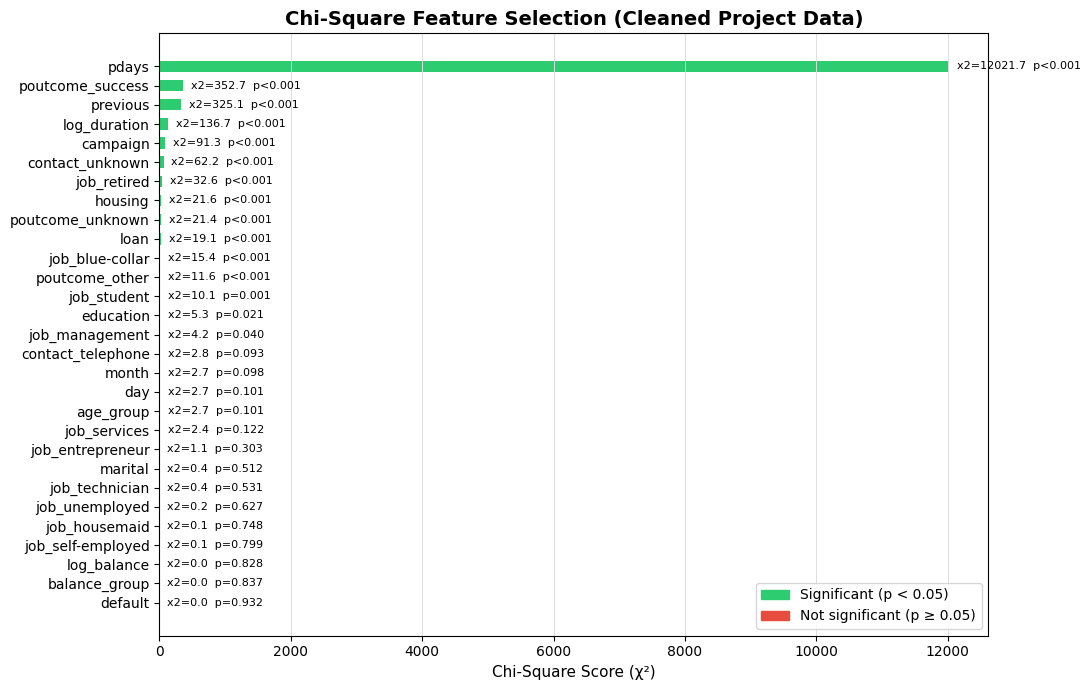

In [33]:
from sklearn.feature_selection import chi2
import matplotlib.patches as mpatches

# 1. Adapting Thanos code to the prepped dataset
# X and y remain the same as previously defined
df_chi = X.copy()
y_chi = y.copy()

# Chi-Square requires non-negative values.
# log_balance might have negatives if balance was negative.
# We shift everything to be 0+ just for this calculation.
df_chi_pos = df_chi.apply(lambda x: x - x.min())

# 2. Run the Chi-Square calculation (Thanos pls check)
chi_scores, p_values = chi2(df_chi_pos, y_chi)

chi_results = (pd.DataFrame({'Feature': df_chi.columns,
                              'Chi2': chi_scores,
                              'p_value': p_values})
               .sort_values('Chi2', ascending=False)
               .reset_index(drop=True))

chi_results['Significant'] = chi_results['p_value'] < 0.05

# 3. Apply visualization style
# Note: Ensure these color variables are defined or use standard hex codes
C_SIG = '#2ecc71' # Green for significant
C_NS  = '#e74c3c' # Red for not significant
BG    = 'white'
GRID  = '#dddddd'

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.set_facecolor(BG)

# Reverse for the horizontal bar chart
rev = chi_results.iloc[::-1].reset_index(drop=True)
colors = [C_SIG if s else C_NS for s in rev['Significant']]

bars = ax.barh(rev['Feature'], rev['Chi2'], color=colors, height=0.6)

# Labels and Styling
ax.set_xlabel('Chi-Square Score (χ²)', fontsize=11)
ax.set_title('Chi-Square Feature Selection (Cleaned Project Data)', fontsize=14, fontweight='bold')
ax.xaxis.grid(True, color=GRID, linewidth=0.7)

# Add the p-value text labels (Thanos check this too pls)
max_chi = chi_results['Chi2'].max()
for bar, (_, row) in zip(bars, rev.iterrows()):
    pval = row['p_value']
    plabel = "p<0.001" if pval < 0.001 else f"p={pval:.3f}"
    ax.text(bar.get_width() + max_chi * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"x2={row['Chi2']:.1f}  {plabel}",
            va='center', ha='left', fontsize=8)

ax.legend(handles=[mpatches.Patch(color=C_SIG, label='Significant (p < 0.05)'),
                   mpatches.Patch(color=C_NS,  label='Not significant (p ≥ 0.05)')],
          loc='lower right')

plt.tight_layout()
plt.show()

# Export this list for our "Voting" step
chi2_list = chi_results[chi_results['Significant'] == True]['Feature'].tolist()

**Voting Consensus Code**

This script aggregates the "opinions" of all four methods:

- Correlation (Linear relationship)

- Decision Tree (Gini Importance/Information Gain)

- Naïve Bayes (Permutation Importance)

- Chi-Square (Statistical Independence)

In [34]:
import pandas as pd

# 1. GATHER ALL FEATURE LISTS
# Correlation List (Absolute values)
list_corr = df_model.corr()['subscription'].abs().sort_values(ascending=False).head(14).index.tolist()
if 'subscription' in list_corr: list_corr.remove('subscription')

# Model and Statistical Lists
list_dt = dt_top_20.head(13).index.tolist()
list_nb = nb_top_20.head(13).index.tolist()
list_chi = chi_results.head(13)['Feature'].tolist()

# 2. BUILD THE VOTING SCOREBOARD
votes = pd.DataFrame(index=X.columns)
votes['Correlation']  = votes.index.isin(list_corr).astype(int)
votes['DecisionTree'] = votes.index.isin(list_dt).astype(int)
votes['NaiveBayes']   = votes.index.isin(list_nb).astype(int)
votes['Chi2']         = votes.index.isin(list_chi).astype(int)
votes['Total_Votes']  = votes.sum(axis=1)

# Sort temporarily for ranking logic
ranked_features = votes.sort_values(by=['Total_Votes', 'Correlation'], ascending=False)

# 3. APPLY THE "GOLDEN TICKET" RULE (Top 3 protection)
# We ensure the top 3 of any individual method is kept, regardless of total votes
top_3_corr = set(list_corr[:3])
top_3_dt   = set(list_dt[:3])
top_3_nb   = set(list_nb[:3])
top_3_chi  = set(list_chi[:3])

golden_tickets = top_3_corr | top_3_dt | top_3_nb | top_3_chi

# 4. FINAL SELECTION
# Combine Golden Tickets with the highest overall voters to get our target set
current_top_13 = set(ranked_features.head(13).index.tolist())
final_selection_set = list(golden_tickets | current_top_13)

# Create a final DataFrame for display
df_final_features = ranked_features.loc[final_selection_set].copy()
df_final_features['Golden_Ticket'] = df_final_features.index.map(lambda x: '⭐' if x in golden_tickets else '')
df_final_features = df_final_features.sort_values(by=['Total_Votes', 'Correlation'], ascending=False)

# 5. DISPLAY RESULTS AS A TABLE
print(f"Total Unique Features Selected: {len(df_final_features)}")
print("-" * 60)
# Renaming for a cleaner table output
display_table = df_final_features[['Total_Votes', 'Golden_Ticket', 'Correlation', 'DecisionTree', 'NaiveBayes', 'Chi2']]
print(display_table.to_string())

# Save this list for your next modeling step
final_feature_selection = df_final_features.index.tolist()

Total Unique Features Selected: 13
------------------------------------------------------------
                  Total_Votes Golden_Ticket  Correlation  DecisionTree  NaiveBayes  Chi2
pdays                       4             ⭐            1             1           1     1
poutcome_success            4             ⭐            1             1           1     1
log_duration                4             ⭐            1             1           1     1
job_retired                 3             ⭐            1             0           1     1
loan                        3                          1             0           1     1
education                   3                          1             1           1     0
contact_unknown             3             ⭐            1             1           0     1
housing                     3                          1             0           1     1
job_blue-collar             3                          1             1           0     1
poutcome_unkno

**Filtered models**

In [35]:
# 1. Create the reduced feature sets using your final selection
X_train_reduced = X_train[final_feature_selection]
X_test_reduced = X_test[final_feature_selection]

# 2. Re-train the models on the REDUCED data
dt_model_v2 = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt_model_v2.fit(X_train_reduced, y_train)
dt_preds_v2 = dt_model_v2.predict(X_test_reduced)

nb_model_v2 = GaussianNB()
nb_model_v2.fit(X_train_reduced, y_train)
nb_preds_v2 = nb_model_v2.predict(X_test_reduced)

# 3. Print the comparison
print("--- REDUCED MODEL PERFORMANCE ---")
print_metrics("Decision Tree (Reduced)", y_test, dt_preds_v2)
print_metrics("Naïve Bayes (Reduced)", y_test, nb_preds_v2)

--- REDUCED MODEL PERFORMANCE ---
--- Decision Tree (Reduced) ---
Accuracy:  0.7799
Precision: 0.3166
Recall:    0.7885
FPR:       0.2213
F1-Score:  0.4518

--- Naïve Bayes (Reduced) ---
Accuracy:  0.8617
Precision: 0.4037
Recall:    0.4231
FPR:       0.0813
F1-Score:  0.4131



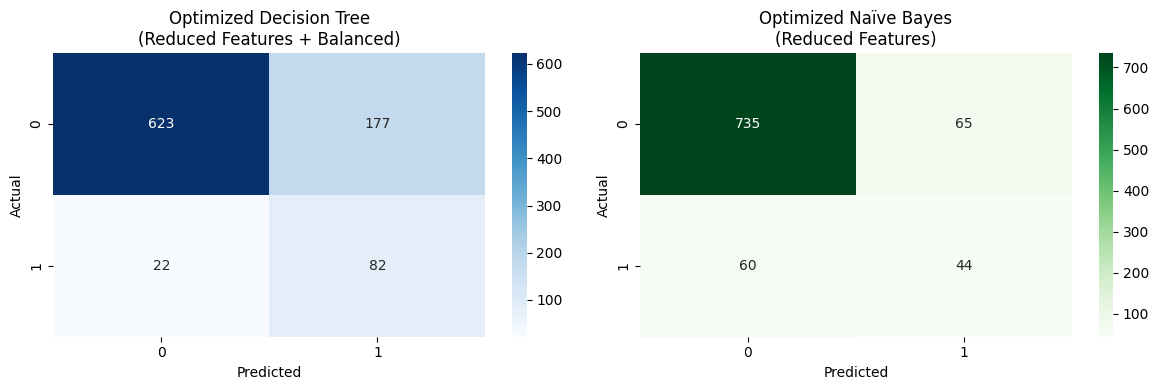

In [36]:
# Visual Comparison: Confusion Matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, dt_preds_v2), annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Optimized Decision Tree\n(Reduced Features + Balanced)')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, nb_preds_v2), annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Optimized Naïve Bayes\n(Reduced Features)')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

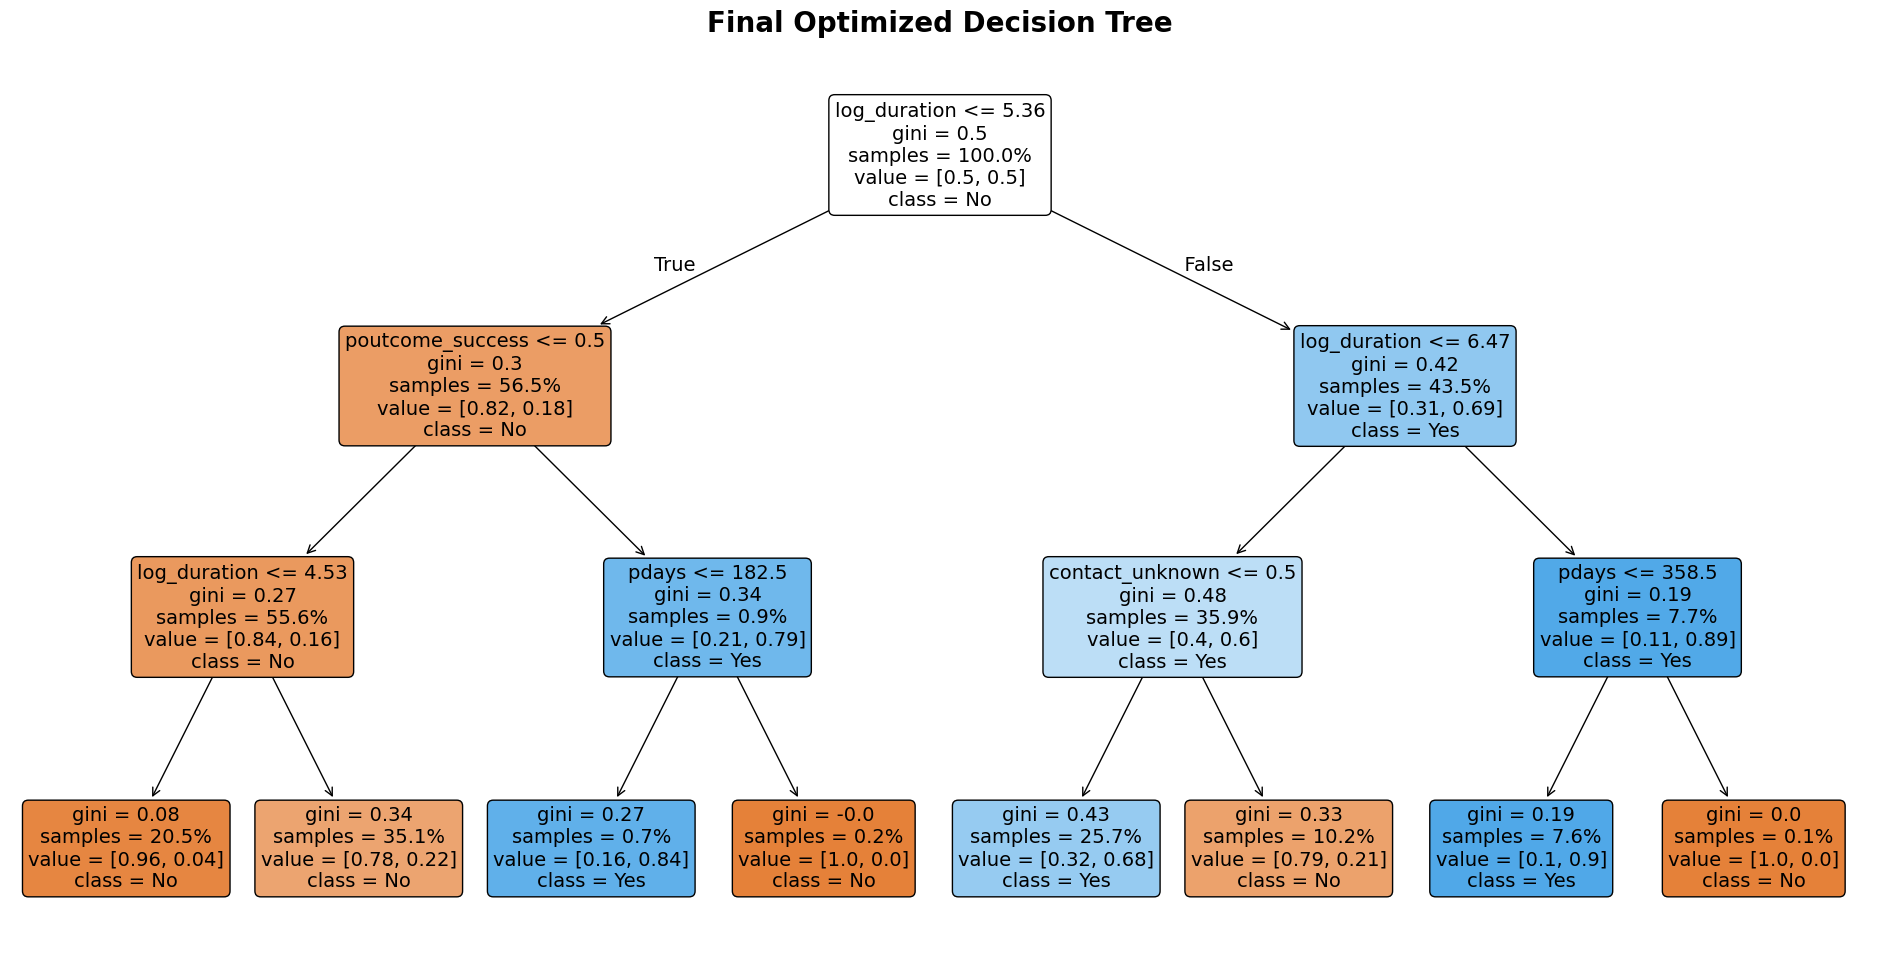

In [37]:
from sklearn.tree import plot_tree

# 1. Initialize and fit the tree on your SELECTED 21 features
# We keep depth 3 so the image doesn't become a "wall of text"
dt_viz = DecisionTreeClassifier(max_depth=3,
                                 class_weight='balanced',
                                 random_state=42)
dt_viz.fit(X_train_reduced, y_train)

# 2. Plotting the results
plt.figure(figsize=(24, 12)) # Large size for readability

plot_tree(dt_viz,
          feature_names=final_feature_selection, # Uses your 21 selected features
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          proportion=True,
          precision=2,
          fontsize=14)

plt.title('Final Optimized Decision Tree', fontsize=20, fontweight='bold')
plt.show()

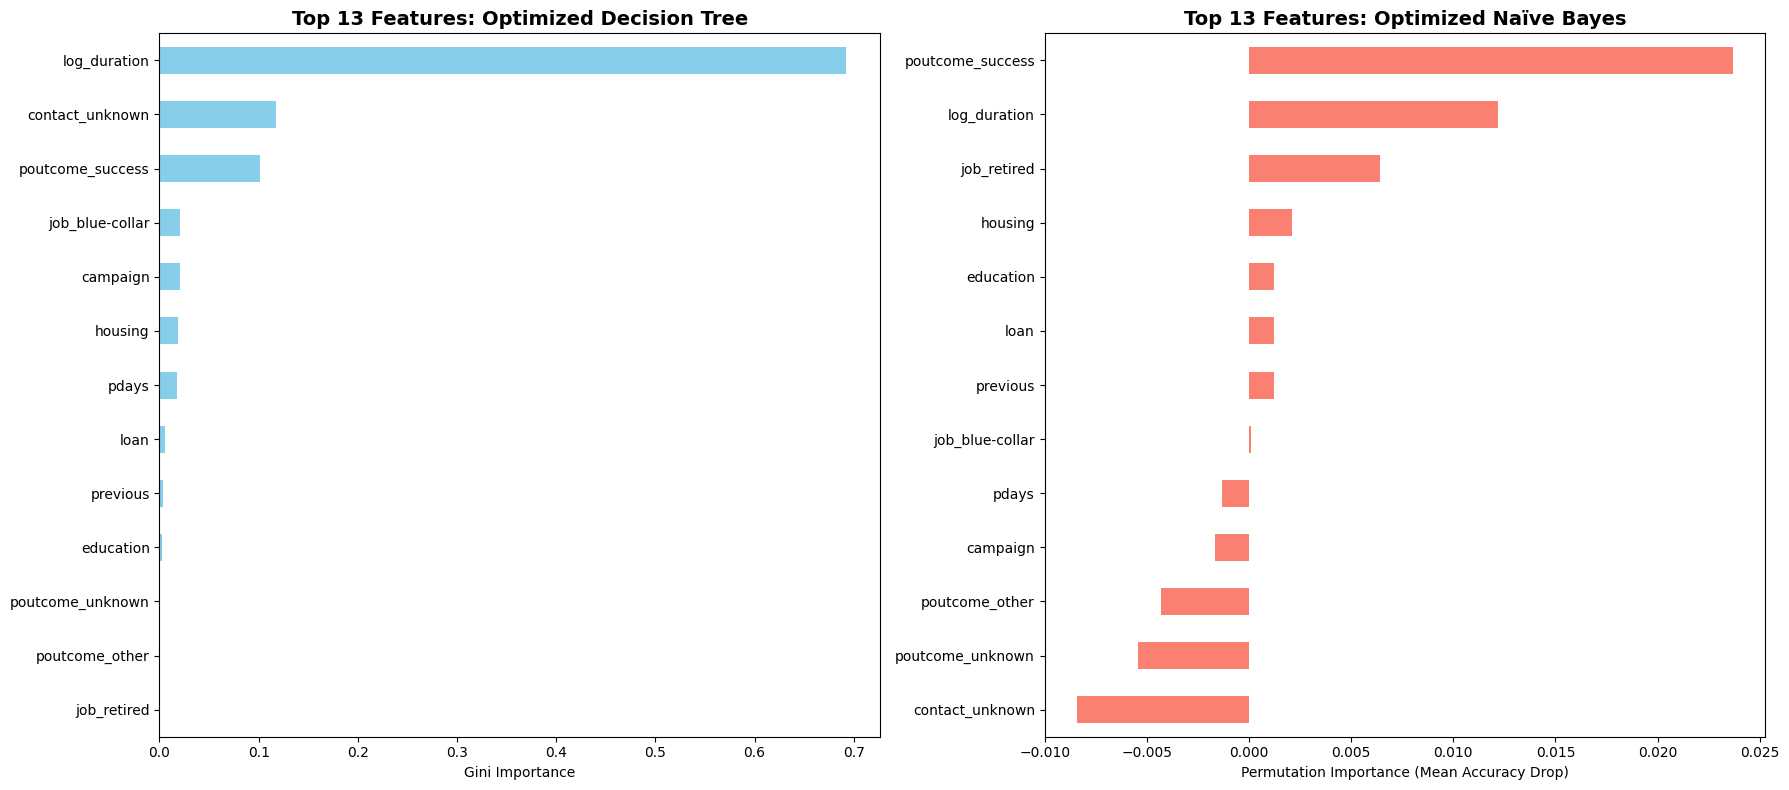

--- Top 13: Optimized Decision Tree ---
log_duration        0.691943
contact_unknown     0.117542
poutcome_success    0.101661
job_blue-collar     0.021163
campaign            0.020707
housing             0.018366
pdays               0.017189
loan                0.005726
previous            0.003571
education           0.002133
job_retired         0.000000
poutcome_unknown    0.000000
poutcome_other      0.000000
dtype: float64

--- Top 13: Optimized Naïve Bayes ---
poutcome_success    0.023673
log_duration        0.012168
job_retired         0.006416
housing             0.002102
education           0.001217
loan                0.001217
previous            0.001217
job_blue-collar     0.000111
pdays              -0.001327
campaign           -0.001659
poutcome_other     -0.004314
poutcome_unknown   -0.005420
contact_unknown    -0.008407
dtype: float64


In [38]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Decision Tree Feature Importance (Optimized) ---
# Use 'dt_final' and 'final_feature_selection'
dt_final_importances = pd.Series(dt_model_v2.feature_importances_, index=final_feature_selection)
dt_final_top_13 = dt_final_importances.sort_values(ascending=False).head(13)

# --- 2. Naïve Bayes Feature Importance (Optimized) ---
# Use 'nb_final' and the reduced 'X_test_reduced'
nb_final_perm = permutation_importance(nb_model_v2, X_test_reduced, y_test, n_repeats=10, random_state=42)
nb_final_importances = pd.Series(nb_final_perm.importances_mean, index=final_feature_selection)
nb_final_top_13 = nb_final_importances.sort_values(ascending=False).head(13)

# --- 3. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Final Decision Tree Plot
dt_final_top_13.sort_values().plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title('Top 13 Features: Optimized Decision Tree', fontsize=14, fontweight='bold')
ax1.set_xlabel('Gini Importance')

# Final Naïve Bayes Plot
nb_final_top_13.sort_values().plot(kind='barh', ax=ax2, color='salmon')
ax2.set_title('Top 13 Features: Optimized Naïve Bayes', fontsize=14, fontweight='bold')
ax2.set_xlabel('Permutation Importance (Mean Accuracy Drop)')

plt.tight_layout()
plt.show()

# --- 4. Print Ranked Lists ---
print("--- Top 13: Optimized Decision Tree ---")
print(dt_final_top_13)
print("\n--- Top 13: Optimized Naïve Bayes ---")
print(nb_final_top_13)

--- FINAL MODEL COMPARISON ---
                Accuracy  Precision  Recall     FPR  F1-Score
DT (Original)     0.7622     0.2982  0.7885  0.2412    0.4327
DT (Optimized)    0.7799     0.3166  0.7885  0.2212    0.4518
NB (Original)     0.8529     0.3802  0.4423  0.0938    0.4089
NB (Optimized)    0.8617     0.4037  0.4231  0.0812    0.4131
DT (Selected)     0.7223     0.2724  0.8462  0.2938    0.4122
NB (Selected)     0.8717     0.4333  0.3750  0.0638    0.4021


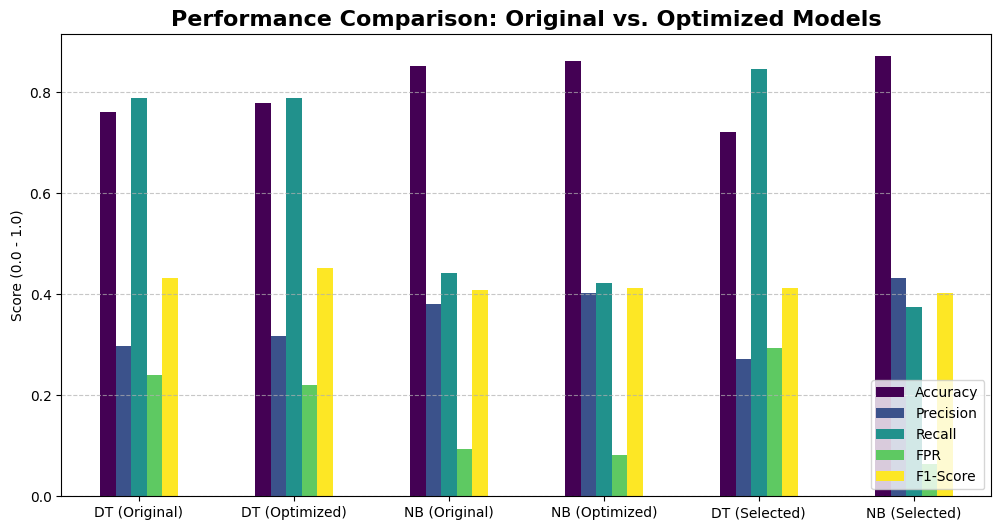

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Define a helper function to collect metrics into a dictionary
def get_metrics_dict(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'FPR': (confusion_matrix(y_true, y_pred)[0, 1]
                / confusion_matrix(y_true, y_pred)[0, :].sum()),
        'F1-Score': f1_score(y_true, y_pred)
    }

# 2. Collect metrics for all 4 models
# Assumes you kept your original predictions (dt_preds, nb_preds)
# and your final predictions (dt_preds_final, nb_preds_final)
comparison_data = {
    'DT (Original)':  get_metrics_dict(y_test, dt_preds),
    'DT (Optimized)': get_metrics_dict(y_test, dt_preds_v2),
    'NB (Original)':  get_metrics_dict(y_test, nb_preds),
    'NB (Optimized)': get_metrics_dict(y_test, nb_preds_v2),
    'DT (Selected)': get_metrics_dict(y_test, dt_preds_v3),
    'NB (Selected)': get_metrics_dict(y_test, nb_preds_v3)
}

# 3. Create the Comparison Table
df_compare = pd.DataFrame(comparison_data).T

# 4. Highlight the best scores for each metric
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #d4edda' if v else '' for v in is_max]

print("--- FINAL MODEL COMPARISON ---")
print(df_compare.round(4))

# 5. Visual Comparison Chart
df_compare.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Performance Comparison: Original vs. Optimized Models', fontsize=16, fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**No duration test for reverse causality**

--- DURATION IMPACT ANALYSIS ---
         Metric  With Duration (Optimized)  Without Duration (Real-World)
0  Recall (Yes)                     0.7885                         0.5481
1      F1-Score                     0.4518                         0.2780
2     Precision                     0.3166                         0.1863


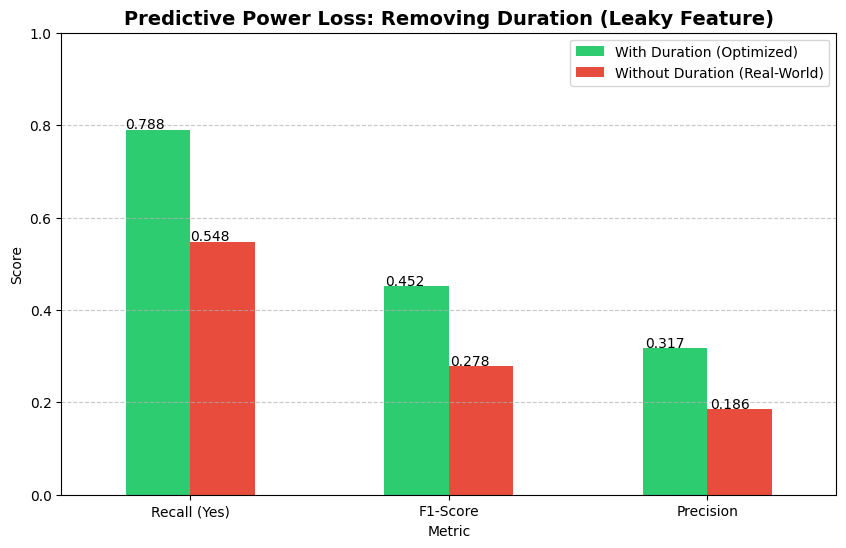

In [40]:
from sklearn.metrics import recall_score, f1_score, precision_score
import pandas as pd
import matplotlib.pyplot as plt

# 1. Use the optimized 13 features from your Golden Ticket/Consensus logic
# Assuming 'final_feature_selection' is your list of 13 features
test_features_no_dur = [f for f in final_feature_selection if f != 'log_duration']

# 2. Train the "Shadow Model" (No-Duration version)
# We keep hyperparameters identical to your optimized model for a fair fight
stress_test_model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
stress_test_model.fit(X_train[test_features_no_dur], y_train)

# 3. Generate Predictions
stress_preds = stress_test_model.predict(X_test[test_features_no_dur])

# 4. Compare with your existing Optimized Results
# This uses your actual dt_preds_v2 from the optimized model
duration_results = {
    'Metric': ['Recall (Yes)', 'F1-Score', 'Precision'],
    'With Duration (Optimized)': [
        recall_score(y_test, dt_preds_v2),
        f1_score(y_test, dt_preds_v2),
        precision_score(y_test, dt_preds_v2)
    ],
    'Without Duration (Real-World)': [
        recall_score(y_test, stress_preds),
        f1_score(y_test, stress_preds),
        precision_score(y_test, stress_preds)
    ]
}

df_stress_test = pd.DataFrame(duration_results)

print("--- DURATION IMPACT ANALYSIS ---")
print(df_stress_test.round(4))

# 5. Visualization
ax = df_stress_test.set_index('Metric').plot(kind='bar', figsize=(10, 6), color=['#2ecc71', '#e74c3c'])
plt.title('Predictive Power Loss: Removing Duration (Leaky Feature)', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.0) # Keeps scale consistent for the presentation
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Add data labels on top of bars for the presentation slide
for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 3)), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.show()

**Model Testing (The "Proof"):**

To demonstrate the practical use of our model, we created a "Sample Customer" profile. We can use our Filtered Decision Tree to predict if this specific individual is a good target for the bank.

In [41]:
# 1. Create a template using the REDUCED feature set
# This ensures we have the correct 21 columns
test_customer = X_test_reduced.iloc[[0]].copy()

# 2. Modify the profile to match your persona
# IMPORTANT: Use the exact column names from your final_feature_selection list
# If you used 'age_group' or 'log_duration' in your top 20, update those here:

if 'age' in test_customer.columns: test_customer['age'] = 55
if 'age_group' in test_customer.columns: test_customer['age_group'] = 3 # Assuming 3 is "Older"
if 'balance' in test_customer.columns: test_customer['balance'] = 5000
if 'log_duration' in test_customer.columns: test_customer['log_duration'] = 6.5 # High duration

test_customer['housing'] = 0    # No mortgage
test_customer['loan'] = 0       # No loan
test_customer['education'] = 2  # Tertiary/Secondary
test_customer['campaign'] = 1   # First contact this campaign

# Handling Categorical (One-Hot) columns if they are in your Top 20:
if 'poutcome_success' in test_customer.columns: test_customer['poutcome_success'] = 1
if 'job_retired' in test_customer.columns: test_customer['job_retired'] = 1

# 3. Predict using the FINAL OPTIMIZED models
# Using the Decision Tree as it's the best "Hunter" model we made
res = dt_model_v2.predict(test_customer)
prob = dt_model_v2.predict_proba(test_customer)

status = "SUBSCRIBE" if res[0] == 1 else "NOT SUBSCRIBE"

print("--- Persona Prediction Analysis ---")
print(f"Prediction for Sample Customer: {status}")
print(f"Confidence of 'Yes' (Subscription): {prob[0][1]:.2%}")
print(f"Confidence of 'No' (Rejection): {prob[0][0]:.2%}")

--- Persona Prediction Analysis ---
Prediction for Sample Customer: SUBSCRIBE
Confidence of 'Yes' (Subscription): 91.74%
Confidence of 'No' (Rejection): 8.26%


**Bonus 2: K-MEANS CLUSTERING**

In [42]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# A. Standardize and Cluster using all 9 features
cluster_features = df_model[['age_group', 'education', 'log_balance', 'log_duration', 'campaign', 'pdays', 'previous', 'day', 'month']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_model['cluster'] = kmeans.fit_predict(scaled_features)

# B. THE SYNC: This is the missing piece!
# We map the clusters found in the model back to the raw numbers in df_prep
df_prep['cluster'] = df_model['cluster']

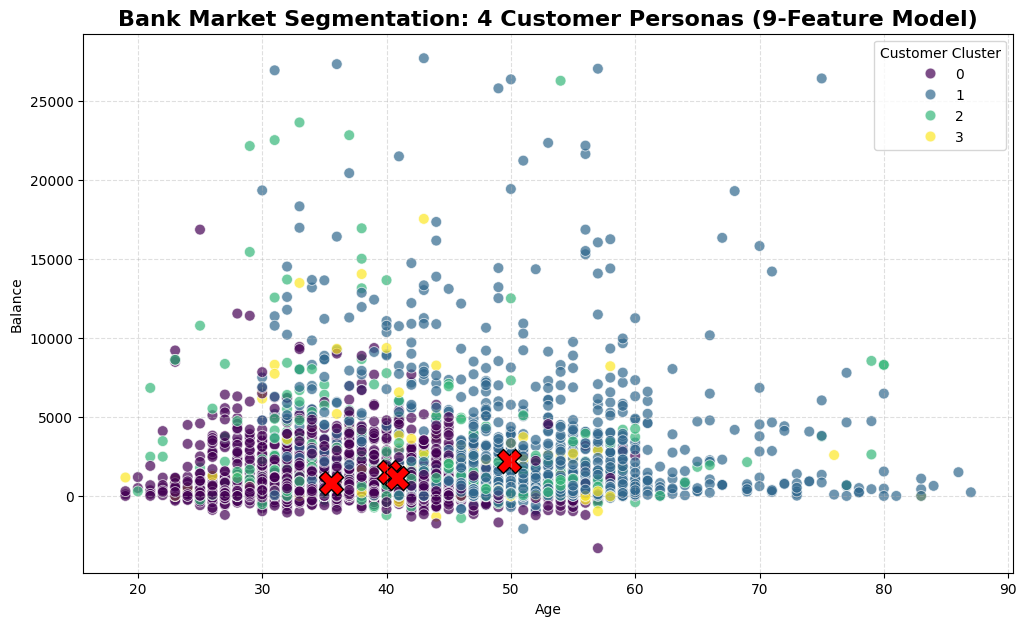

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
# We use df_prep now because it has the 'age' and 'balance' columns AND the synced cluster labels
sns.scatterplot(data=df_prep, x='age', y='balance', hue='cluster', palette='viridis', s=60, alpha=0.7)

# Centroids for multi-feature clusters are the mean of each cluster's coordinates
for i in range(4):
    plt.scatter(df_prep[df_prep['cluster']==i]['age'].mean(),
                df_prep[df_prep['cluster']==i]['balance'].mean(),
                s=300, c='red', marker='X', edgecolors='black')

plt.title('Bank Market Segmentation: 4 Customer Personas (9-Feature Model)', fontsize=16, fontweight='bold')
plt.xlabel('Age'); plt.ylabel('Balance')
plt.legend(title='Customer Cluster', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


In [44]:
# Setup Helpers
age_rev_map = {0: 'Under 30', 1: '30-45', 2: '46-60', 3: '60+'}
education_map = {1: 'Primary', 2: 'Secondary', 3: 'Tertiary', 0: 'Unknown'}

for cluster_id in sorted(df_model['cluster'].unique()):
    # Pulling from the synced subsets
    raw_subset = df_prep[df_prep['cluster'] == cluster_id]
    model_subset = df_model[df_model['cluster'] == cluster_id]

    success_rate = (model_subset['subscription'] == 1).mean() * 100
    avg_campaign = raw_subset['campaign'].mean()
    med_pdays = raw_subset['pdays'].median()

    # Strategy Logic based on your project goals
    if cluster_id == 2:
        strategy = "⭐ PRIMARY TARGET: High Conversion / Ideal Profile"
    elif success_rate >= 10:
        strategy = "✅ SECONDARY TARGET: Stable Prospects"
    elif avg_campaign > 8 or success_rate < 5:
        strategy = "❌ CEASE CONTACT: High Fatigue / Low ROI"
    else:
        strategy = "⚠️ LOW PRIORITY: Monitor for Changes"

    persona_data = {
        "Attribute": ["Final Recommendation", "Target Demographic", "Actual Median Balance",
                      "Top Job / Industry", "Education Level", "Home Ownership",
                      "Campaign Fatigue", "Last Interaction", "SUCCESS RATE (KPI)"],
        "Description": [
            strategy,
            f"Age {int(raw_subset['age'].median())} ({age_rev_map.get(int(model_subset['age_group'].median()), 'Mixed')})",
            f"${raw_subset['balance'].median():,.2f}",
            raw_subset['job'].mode()[0].title(),
            education_map.get(model_subset['education'].mode()[0], "Unknown"),
            f"{round(model_subset['housing'].mean() * 100, 1)}% have housing loans",
            f"{avg_campaign:.1f} avg contacts",
            "Never (Fresh Lead)" if med_pdays == -1 else f"{int(med_pdays)} days ago",
            f"{success_rate:.1f}%"
        ]
    }

    print(f"\n{'='*80}\n CUSTOMER PROFILE: CLUSTER {cluster_id}\n{'='*80}")
    print(pd.DataFrame(persona_data).to_string(index=False, justify='left'))


 CUSTOMER PROFILE: CLUSTER 0
Attribute             Description                         
 Final Recommendation ✅ SECONDARY TARGET: Stable Prospects
   Target Demographic                       Age 35 (30-45)
Actual Median Balance                              $340.00
   Top Job / Industry                          Blue-Collar
      Education Level                            Secondary
       Home Ownership             61.9% have housing loans
     Campaign Fatigue                     2.2 avg contacts
     Last Interaction                   Never (Fresh Lead)
   SUCCESS RATE (KPI)                                10.1%

 CUSTOMER PROFILE: CLUSTER 1
Attribute             Description                         
 Final Recommendation ✅ SECONDARY TARGET: Stable Prospects
   Target Demographic                       Age 50 (46-60)
Actual Median Balance                              $693.00
   Top Job / Industry                           Management
      Education Level                            Second

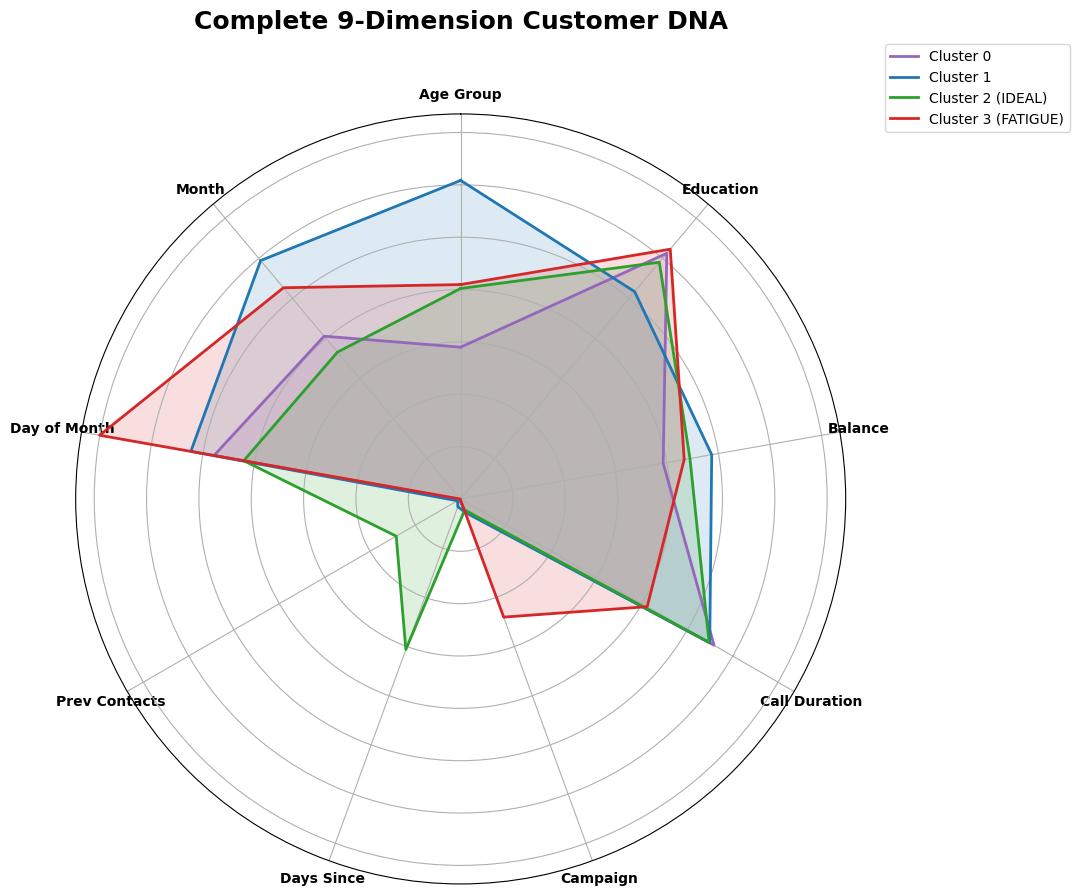

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. The Full 9 Features from your Clustering Model
features = ['age_group', 'education', 'log_balance', 'log_duration',
            'campaign', 'pdays', 'previous', 'day', 'month']

labels = ['Age Group', 'Education', 'Balance', 'Call Duration',
          'Campaign', 'Days Since', 'Prev Contacts', 'Day of Month', 'Month']

# 2. Rescale all 9 for the chart
scaler_mm = MinMaxScaler()
df_rescaled = pd.DataFrame(scaler_mm.fit_transform(df_model[features]), columns=features)
df_rescaled['cluster'] = df_model['cluster'].values

cluster_summary = df_rescaled.groupby('cluster').mean().reset_index()

# 3. Setup Radar Chart with 9 Arms
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

def add_cluster_to_radar(cluster_id, color, name):
    values = cluster_summary.iloc[cluster_id][features].values.tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=name)
    ax.fill(angles, values, color=color, alpha=0.15)

# Plot all 4 clusters to show the total market segmentation
colors = ['#9467bd', '#1f77b4', '#2ca02c', '#d62728'] # Purple, Blue, Green, Red
names = ['Cluster 0', 'Cluster 1', 'Cluster 2 (IDEAL)', 'Cluster 3 (FATIGUE)']

for i in range(4):
    add_cluster_to_radar(i, colors[i], names[i])

# Visual Polish
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
ax.set_yticklabels([])

plt.title('Complete 9-Dimension Customer DNA', size=18, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()